In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

### Задача сегментации клиентов!

Сюжет: автомобильная компания провела внутреннее маркетинговое исследование и выявила, что клиенты делятся на 4 различных сегмента.

В зависимости от принадлежности к той или иной группе, различным клиентам предлагаются различные пакеты услуг, приставляются особого рода менеджеры; на этих клиентов воздействуют отличающимися друг от друга маркетинговыми интсрументами и т.д.

Данная политика показала себя успешной. Счастье клиентов стало расти, ровно как и продажи!

Теперь организация планирует выйти на новый рынок в соседнем регионе. Чтобы сразу показать конкурентам, где раки зимуют, управляющие планируют построить модель, определяющую, к какому сегменту относится тот или иной клиент. Это позволит на новом рынке лучше прощупать почву и быстрее найти нужный язык с новыми покупателями.

В качестве данных - информация о уже текущих сегментированных клиентах (на внутреннем рынке).

Сегменты бывают: A, B, C, D

Тогда задача, которую планируем решать - множественная классификация!



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_columns = 500

df = pd.read_csv("segmentation_data.csv")
df.shape

(8068, 11)

In [6]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [7]:
df['Ever_Married'].value_counts()

Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64

Описание колонок:

1. **ID** - уникальный идентификатор клиента
2. **Gender** - пол
3. **Ever_Married** - статус замужества
4. **Age** - возраст
5. **Graduated** - дипломирован ли?
6. **Profession** - сфера деятельности
7. **Work_Experience** - опыт работы (в годах)
8. **Spending_Score** - уровень затрат
9. **Family_Size** - количество членов семьи
10. **Var_1** - анонимная категория клиента
11. **Segmentation** - сегмент клиента

**Наша целевая переменная - сегмент клиента.**

In [8]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [10]:
### Посмотрим на некатегориальные колонки

numeric_columns = df.loc[:,df.dtypes!=np.object_].columns
df.loc[:,df.dtypes!=np.object_].head(2)

,ID,Age,Work_Experience,Family_Size
0,462809,22,1.0,4.0
1,462643,38,NaN,3.0


In [11]:
numeric_columns

Index(['ID', 'Age', 'Work_Experience', 'Family_Size'], dtype='object')

In [12]:
### Занесем ID в индекс

df = df.set_index("ID")

numeric_columns = numeric_columns.drop("ID")

In [13]:
### Посмотрим на категориальные колонки

categorical_columns = df.loc[:,df.dtypes==np.object_].columns
df.loc[:,df.dtypes==np.object_].head(2)

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
ID,,,,,,,
462809,Male,No,No,Healthcare,Low,Cat_4,D
462643,Female,Yes,Yes,Engineer,Average,Cat_4,A


### EDA

In [14]:
df.shape

(8068, 10)

In [15]:
### Есть ли пропуски?

df.describe()

,Age,Work_Experience,Family_Size
count,8068.000000,7239.000000,7733.000000
mean,43.466906,2.641663,2.850123
std,16.711696,3.406763,1.531413
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [17]:
### Заполним средним

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

In [18]:
df[numeric_columns].isna().sum()

Age                0
Work_Experience    0
Family_Size        0
dtype: int64

In [19]:
df[numeric_columns].corr()

,Age,Work_Experience,Family_Size
Age,1.000000,-0.179361,-0.273291
Work_Experience,-0.179361,1.000000,-0.058702
Family_Size,-0.273291,-0.058702,1.000000


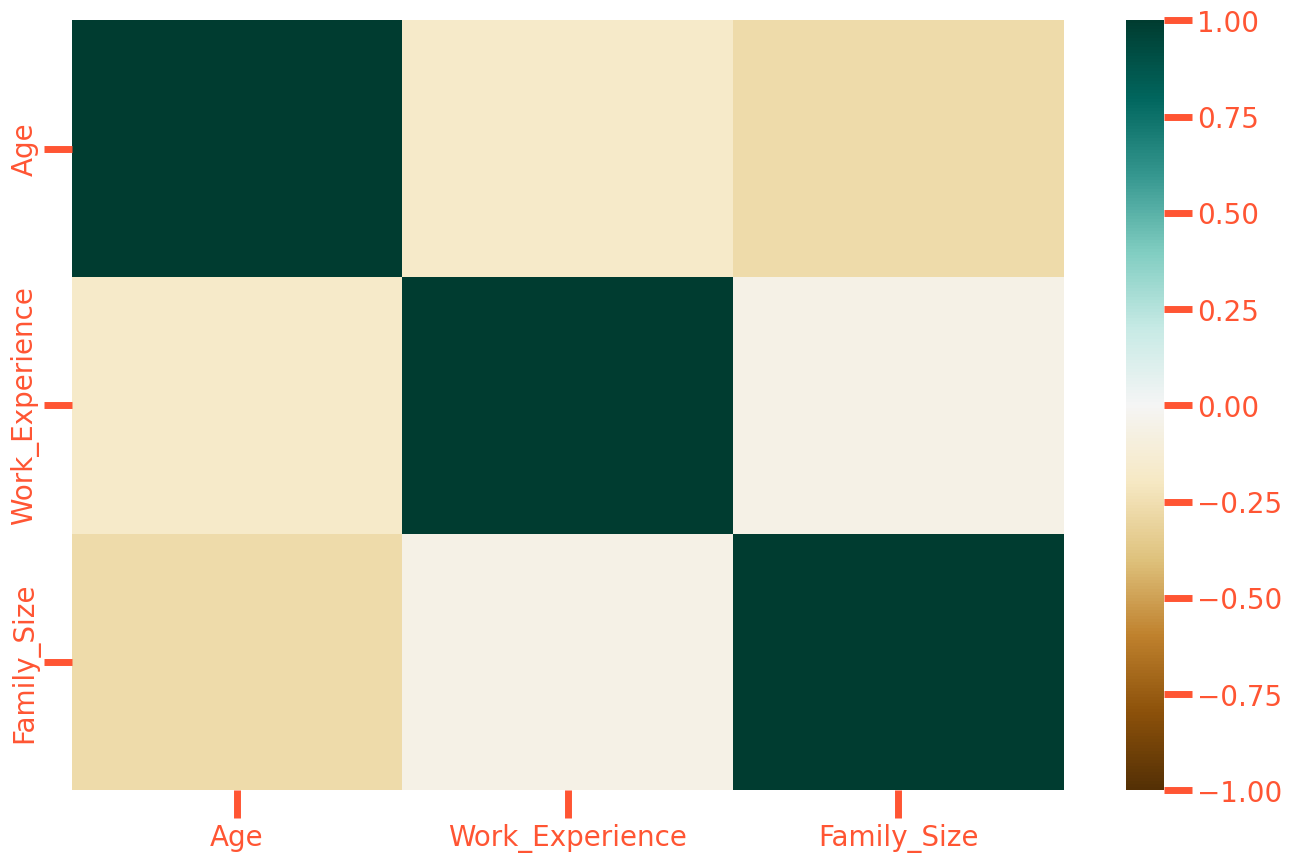

In [21]:
### Изобразим в виде Тепловой карты

import seaborn as sns

fig = plt.figure()

fig.set_size_inches(16, 10)

sns.heatmap(df[numeric_columns].corr(),
            xticklabels=numeric_columns,
            yticklabels=numeric_columns,
            cmap='BrBG',
            vmin=-1,
            vmax=1)

plt.show()

In [22]:
### Секретные функции для фильтрации признаков

def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(df[numeric_columns], 10))

Top Absolute Correlations
Age              Family_Size        0.273291
                 Work_Experience    0.179361
Work_Experience  Family_Size        0.058702
dtype: float64


In [23]:
### Посмотрим на квазиконстантые признаки

from sklearn.feature_selection import VarianceThreshold


cutter = VarianceThreshold(threshold=0.1)
cutter.fit(df[numeric_columns])

cutter.get_feature_names_out()

array(['Age', 'Work_Experience', 'Family_Size'], dtype=object)